# Reading raw SmartSolo DLD files directly

`lib/smartsolo_dld.py` reads the node's own `seisNNN{X,Y,Z}.DLD` files – no SoloLite export needed – and plugs them into the location/selection/extraction tools, which can write MiniSEED, SEG-Y and StationXML. The format notes are in [`docs/DLD_FORMAT.md`](../docs/DLD_FORMAT.md).

Sample data in `data/nodes/`: two nodes recording side by side in a test (453038428, 453038431, 250 sps, with logs) and two Antarctic recordings without logs (453022317 DML, 453027665, 1000 sps).

In [1]:
import sys; sys.path.insert(0, "../lib")
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from obspy import UTCDateTime, read
import smartsolo_dld as dld, smartsolo_locate as loc, smartsolo_waveforms as wf
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
NODES = Path("../data/nodes")
dld_files = sorted(NODES.rglob("*.DLD")); [str(f.relative_to(NODES)) for f in dld_files]

['453022317/seis001X.DLD',
 '453022317/seis001Y.DLD',
 '453022317/seis001Z.DLD',
 '453027665/seis006X.DLD',
 '453027665/seis006Y.DLD',
 '453027665/seis006Z.DLD',
 '453038428/seis000X.DLD',
 '453038428/seis000Y.DLD',
 '453038428/seis000Z.DLD',
 '453038431/seis000X.DLD',
 '453038431/seis000Y.DLD',
 '453038431/seis000Z.DLD']

## 1. File header
The 512-byte header has the serial, firmware, start/end time, position and script name – so files can be identified even if they were renamed or mixed up on a drive.

In [2]:
pd.DataFrame([dld.read_dld_header(f) for f in dld_files]).drop(columns=["magic", "unknown_0x060", "unknown_0x120"])

,version,serial,hardware_id,project_name,bootloader,firmware,start,end,start_tick_ms,end_tick_ms,duration_s,latitude,longitude,altitude,script_name,component,file_index,unknown_0x100,file_size
0,2,453022317,80004000001,DML,V1.0.1.7,V1.0.8.1be,2024-12-25 18:08:57+00:00,2024-12-25 18:11:59+00:00,10076317832416,10076318014416,182.0,-71.549441,11.118683,1642.000000,dmlparameterscript,X,1,"(0, 18, 171, 87, 0, 0, 0)",562688
1,2,453022317,80004000001,DML,V1.0.1.7,V1.0.8.1be,2024-12-25 18:08:57+00:00,2024-12-25 18:11:59+00:00,10076317832416,10076318014416,182.0,-71.549441,11.118683,1642.000000,dmlparameterscript,Y,1,"(0, 18, 171, 87, 0, 0, 0)",562688
2,2,453022317,80004000001,DML,V1.0.1.7,V1.0.8.1be,2024-12-25 18:08:57+00:00,2024-12-25 18:11:59+00:00,10076317832416,10076318014416,182.0,-71.549441,11.118683,1642.000000,dmlparameterscript,Z,1,"(0, 18, 171, 87, 0, 0, 0)",562688
3,2,453027665,80004000001,DML,V1.0.1.8,V1.1.2.0be,2025-02-11 20:37:18+00:00,2025-02-11 20:38:30+00:00,10106305104488,10106305176488,72.0,-66.282287,110.530820,27.700001,dmlparameterscript,X,6,"(0, 18, 61, 126, 1, 0, 0)",224768
4,2,453027665,80004000001,DML,V1.0.1.8,V1.1.2.0be,2025-02-11 20:37:18+00:00,2025-02-11 20:38:30+00:00,10106305104488,10106305176488,72.0,-66.282287,110.530820,27.700001,dmlparameterscript,Y,6,"(0, 18, 61, 126, 1, 0, 0)",224768
5,2,453027665,80004000001,DML,V1.0.1.8,V1.1.2.0be,2025-02-11 20:37:18+00:00,2025-02-11 20:38:30+00:00,10106305104488,10106305176488,72.0,-66.282287,110.530820,27.700001,dmlparameterscript,Z,6,"(0, 18, 61, 126, 1, 0, 0)",224768
6,2,453038428,80004000001,IGU-16HR 3C 5Hz,V1.0.1.8,V1.1.2.0be,2024-10-08 02:25:23+00:00,2024-10-08 02:34:55+00:00,10028930176160,10028930748160,572.0,39.596207,116.760436,26.000000,HR 3C 5Hz Standard Script,X,0,"(0, 0, 528, 50, 4, 0, 0)",442880
7,2,453038428,80004000001,IGU-16HR 3C 5Hz,V1.0.1.8,V1.1.2.0be,2024-10-08 02:25:23+00:00,2024-10-08 02:34:55+00:00,10028930176160,10028930748160,572.0,39.596207,116.760436,26.000000,HR 3C 5Hz Standard Script,Y,0,"(0, 0, 528, 50, 4, 0, 0)",442880
8,2,453038428,80004000001,IGU-16HR 3C 5Hz,V1.0.1.8,V1.1.2.0be,2024-10-08 02:25:23+00:00,2024-10-08 02:34:55+00:00,10028930176160,10028930748160,572.0,39.596207,116.760436,26.000000,HR 3C 5Hz Standard Script,Z,0,"(0, 0, 528, 50, 4, 0, 0)",442880
9,2,453038431,80004000001,IGU-16HR 3C 5Hz,V1.0.1.8,V1.1.2.0be,2024-10-08 02:25:19+00:00,2024-10-08 02:35:39+00:00,10028930172160,10028930792160,620.0,39.596317,116.760490,22.799999,HR 3C 5Hz Standard Script,X,0,"(0, 0, 576, 86, 5, 0, 0)",479744


## 2. Time tags
After every 1000 samples there is a 72-byte tag with UTC time, a millisecond tick, GPS position and GPS time of week. The tick step gives the sample rate: 4000 ms per 1000 samples → 250 sps.

In [3]:
tags = dld.read_dld_tags(NODES / "453038428" / "seis000Z.DLD")
print(len(tags), "tags; tick steps:", tags.tick_ms.diff().value_counts().to_dict())
tags.head()

144 tags; tick steps: {4000.0: 143}


,block,offset,flag,tick_ms,time,latitude,longitude,phase_error,counter,gps_tow_ms
0,0,3512,0,10028930176160,2024-10-08 02:25:23+00:00,39.596248,116.760446,-1,0,181540000
1,1,6584,0,10028930180160,2024-10-08 02:25:27+00:00,39.596245,116.760446,0,0,181544000
2,2,9656,0,10028930184160,2024-10-08 02:25:31+00:00,39.596245,116.760448,1,0,181548000
3,3,12728,0,10028930188160,2024-10-08 02:25:35+00:00,39.596247,116.760451,0,0,181552000
4,4,15800,0,10028930192160,2024-10-08 02:25:39+00:00,39.596250,116.760452,0,0,181556000


## 3. Read samples

In [4]:
st = dld.read_dld_node(sorted((NODES / "453038428").glob("seis000?.DLD")))
print(st)
st[0].stats.dld.header["firmware"], st[0].stats.coordinates

3 Trace(s) in Stream:
.38428..X | 2024-10-08T02:25:23.000000Z - 2024-10-08T02:34:58.996000Z | 250.0 Hz, 144000 samples
.38428..Y | 2024-10-08T02:25:23.000000Z - 2024-10-08T02:34:58.996000Z | 250.0 Hz, 144000 samples
.38428..Z | 2024-10-08T02:25:23.000000Z - 2024-10-08T02:34:58.996000Z | 250.0 Hz, 144000 samples


('V1.1.2.0be',
 AttribDict({'latitude': 39.59625416666667, 'longitude': 116.76045216666667, 'elevation': 26.0}))

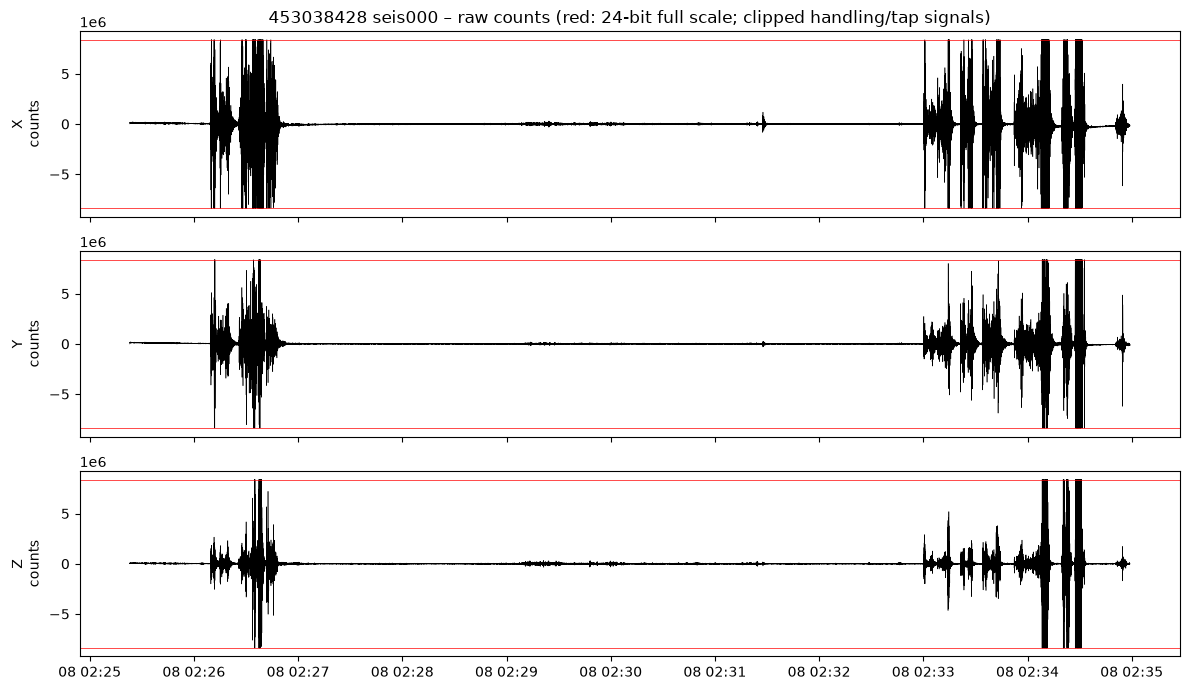

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for a, tr in zip(axes, st):
    a.plot(tr.times("matplotlib"), tr.data, lw=.4, color="k")
    a.set_ylabel(f"{tr.stats.channel}\ncounts"); a.axhline(2**23, color="r", lw=.5); a.axhline(-2**23, color="r", lw=.5)
axes[0].set_title("453038428 seis000 – raw counts (red: 24-bit full scale; clipped handling/tap signals)")
axes[-1].xaxis_date(); plt.tight_layout()

The samples run on smoothly across the 72-byte tags (red lines), i.e. the blocks are contiguous:

median |Δ| at block boundaries: 63.5  elsewhere: 70.0


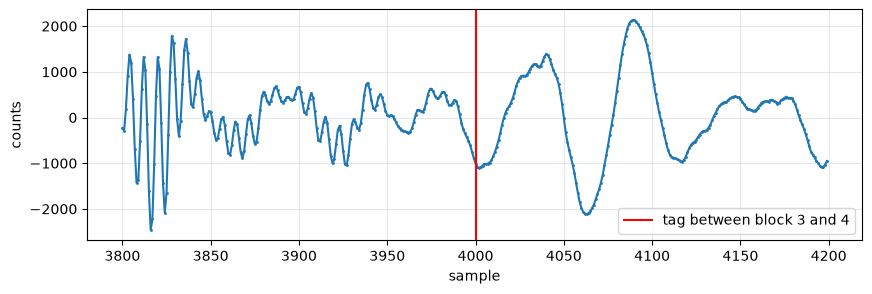

In [6]:
tr = dld.read_dld(NODES / "453027665" / "seis006Y.DLD")[0]
plt.figure(figsize=(10, 3)); i = np.arange(3800, 4200)
plt.plot(i, tr.data[i], ".-", ms=2); plt.axvline(4000, color="r", label="tag between block 3 and 4")
plt.xlabel("sample"); plt.ylabel("counts"); plt.legend(); plt.grid(alpha=.3)
d = np.abs(np.diff(tr.data.astype(float)))
print("median |Δ| at block boundaries:", np.median(d[999::1000]), " elsewhere:", np.median(d))

## 4. Timing check: two nodes side by side
Nodes 453038428 and 453038431 stood ~10 m apart and started 4 s apart. After reading both with the tag times, the same ground motion lines up to within one sample (4 ms): correlation 0.96 on X, lower on Z and Y in this short window (over 4 minutes Z reaches 0.93; Y stays low – the nodes probably point in different directions).

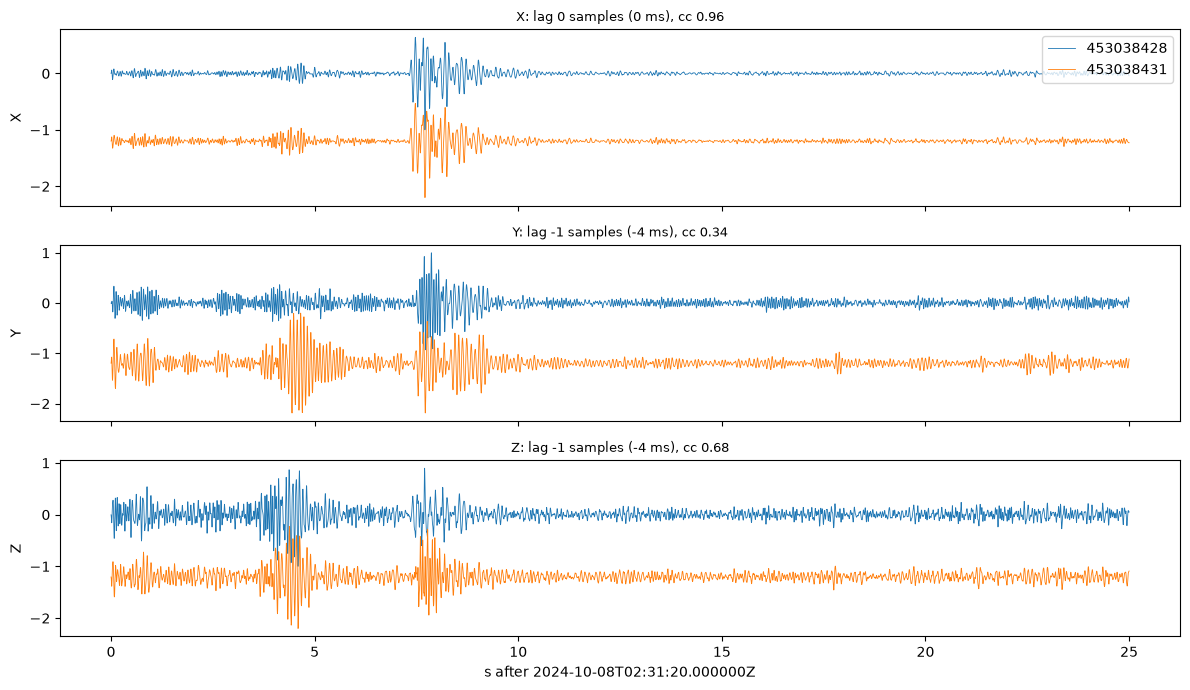

In [7]:
from obspy.signal.cross_correlation import correlate, xcorr_max
t0, t1 = UTCDateTime("2024-10-08T02:31:20"), UTCDateTime("2024-10-08T02:31:45")
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for a, c in zip(axes, "XYZ"):
    x = dld.read_dld(NODES / "453038428" / f"seis000{c}.DLD", starttime=t0, endtime=t1)[0]
    y = dld.read_dld(NODES / "453038431" / f"seis000{c}.DLD", starttime=t0, endtime=t1)[0]
    for tr in (x, y): tr.detrend("demean"); tr.filter("bandpass", freqmin=5, freqmax=40)
    lag, cc = xcorr_max(correlate(x.data, y.data, 250), abs_max=False)
    a.plot(x.times(), x.data / abs(x.data).max(), lw=.6, label="453038428")
    a.plot(y.times(), y.data / abs(y.data).max() - 1.2, lw=.6, label="453038431")
    a.set_ylabel(c); a.set_title(f"{c}: lag {lag} samples ({lag/250*1000:.0f} ms), cc {cc:.2f}", fontsize=9)
axes[0].legend(loc="upper right"); axes[-1].set_xlabel(f"s after {t0}"); plt.tight_layout()

This confirms the relative timing and that the tags are read correctly. The **absolute** convention – whether a tag marks the start of the block before it (`tag_marks="block_start"`, default) or its end – shifts everything by one block (4 s at 250 sps, 1 s at 1000 sps). Settle it once with a SoloLite export of the same file:

```python
dld_tr = dld.read_dld("seis000Z.DLD")[0]
exp_tr = read("exported_by_sololite.miniseed")[0]
dld.compare_with_export(dld_tr, exp_tr)   # lag_s ≈ 0 → block_start is right; ≈ -4 s → use "block_end"
```

## 5. Deployments from logs and from DLD files
Nodes without a log (453022317, 453027665) are located from the GPS positions in their tags; for nodes with a log, the log deployment is kept and widened to cover the recorded data.

In [8]:
dld_deps = loc.build_deployments_from_dld(NODES)
log_deps = loc.build_deployments(NODES)
deps = loc.combine_deployments(log_deps, dld_deps)
deps[["deployment_id", "source", "start", "end", "latitude", "longitude", "elevation", "sample_rate_hz", "channel_1_gain"]]

,deployment_id,source,start,end,latitude,longitude,elevation,sample_rate_hz,channel_1_gain
0,453021267_004,log,2024-12-25 14:26:27+00:00,2025-01-08 09:03:48+00:00,-71.548243,11.115678,1649.400000,1000.0,0.0
1,453022317_dld001,dld,2024-12-25 18:08:57+00:00,2024-12-25 18:11:59.999000+00:00,-71.549451,11.118713,1642.000000,1000.0,NaN
2,453022522_003,log,2024-12-25 15:20:06+00:00,2025-01-08 10:09:20+00:00,-71.550005,11.117645,1643.700000,1000.0,0.0
3,453026127_004,log,2024-09-27 05:53:59+00:00,2024-09-27 06:40:23+00:00,39.596230,116.760429,26.200000,250.0,18.0
4,453027665_dld006,dld,2025-02-11 20:37:18+00:00,2025-02-11 20:38:30.999000+00:00,-66.282303,110.530842,27.700001,1000.0,NaN
5,453038428_002,log,2024-10-08 02:25:23+00:00,2024-10-08 02:34:58.996000+00:00,39.596254,116.760453,32.200000,250.0,18.0
6,453038428_003,log,2024-10-08 02:44:15+00:00,2024-10-08 03:03:27+00:00,39.596248,116.760447,33.050000,250.0,18.0
7,453038431_003,log,2024-10-08 02:25:19+00:00,2024-10-08 02:35:42.996000+00:00,39.596224,116.760425,40.900000,250.0,18.0
8,453038431_004,log,2024-10-08 02:44:03+00:00,2024-10-08 03:03:15+00:00,39.595942,116.759681,68.950000,250.0,18.0
9,453046194_002,log,2026-06-05 01:41:13+00:00,2026-06-05 01:56:49+00:00,39.596054,116.760548,17.600000,500.0,36.0


## 6. Select by area and time, cut, write MiniSEED / SEG-Y / StationXML

In [9]:
index = wf.index_waveforms(NODES)          # DLD headers + tags only
sel = loc.select_deployments(deps, point=(39.5962, 116.7604), radius_km=0.05,
                             start="2024-10-08T02:31:20", end="2024-10-08T02:31:50")
sel[["deployment_id", "distance_km", "sel_start", "sel_end"]]

,deployment_id,distance_km,sel_start,sel_end
5,453038428_002,0.007566,2024-10-08 02:31:20+00:00,2024-10-08 02:31:50+00:00
7,453038431_003,0.003422,2024-10-08 02:31:20+00:00,2024-10-08 02:31:50+00:00


In [10]:
out = Path("../output/dld_demo")
st_m = wf.extract_waveforms(sel, index, out_dir=out / "mseed", out_format="MSEED")
st_s = wf.extract_waveforms(sel, index, out_dir=out / "segy", out_format="SEGY")
inv = wf.build_inventory(sel, stream=st_m, response="auspass")      # includes the 18 dB preamp gain
inv.write(str(out / "stations.xml"), format="STATIONXML")
print(st_m)
print(sorted(str(p.relative_to(out)) for p in out.rglob("*") if p.is_file()))

6 Trace(s) in Stream:
XX.38428..DPE | 2024-10-08T02:31:20.000000Z - 2024-10-08T02:31:49.996000Z | 250.0 Hz, 7500 samples
XX.38428..DPN | 2024-10-08T02:31:20.000000Z - 2024-10-08T02:31:49.996000Z | 250.0 Hz, 7500 samples
XX.38428..DPZ | 2024-10-08T02:31:20.000000Z - 2024-10-08T02:31:49.996000Z | 250.0 Hz, 7500 samples
XX.38431..DPE | 2024-10-08T02:31:20.000000Z - 2024-10-08T02:31:49.996000Z | 250.0 Hz, 7500 samples
XX.38431..DPN | 2024-10-08T02:31:20.000000Z - 2024-10-08T02:31:49.996000Z | 250.0 Hz, 7500 samples
XX.38431..DPZ | 2024-10-08T02:31:20.000000Z - 2024-10-08T02:31:49.996000Z | 250.0 Hz, 7500 samples
['mseed/XX/38428/XX.38428..DPE__20241008T023120Z__20241008T023150Z.mseed', 'mseed/XX/38428/XX.38428..DPN__20241008T023120Z__20241008T023150Z.mseed', 'mseed/XX/38428/XX.38428..DPZ__20241008T023120Z__20241008T023150Z.mseed', 'mseed/XX/38431/XX.38431..DPE__20241008T023120Z__20241008T023150Z.mseed', 'mseed/XX/38431/XX.38431..DPN__20241008T023120Z__20241008T023150Z.mseed', 'mseed/XX/384

Read back and compare with the raw DLD samples (×−1 for the AusPass polarity convention, X → N, Y → E, 250 sps → `DP?`):

In [11]:
raw = dld.read_dld(NODES / "453038428" / "seis000Z.DLD", starttime="2024-10-08T02:31:20", endtime="2024-10-08T02:31:49.996")[0]
m = read(str(next((out / "mseed").rglob("*38428..DPZ*"))))[0]
s = read(str(next((out / "segy").rglob("*38428..DPZ*"))), format="SEGY")[0]
print(m.stats.starttime, s.stats.starttime, raw.stats.starttime)
print("MiniSEED == -DLD:", np.array_equal(m.data, -raw.data), "  SEG-Y == MiniSEED:", np.array_equal(s.data, m.data))
print(inv[0][0][0].response)

2024-10-08T02:31:20.000000Z 2024-10-08T02:31:20.000000Z 2024-10-08T02:31:20.000000Z
MiniSEED == -DLD: True   SEG-Y == MiniSEED: True
Channel Response
	From M/S () to COUNTS ()
	Overall Sensitivity: 2.02916e+09 defined at 15.000 Hz
	1 stages:
		Stage 1: PolesZerosResponseStage from M/S to COUNTS, gain: 2.02916e+09


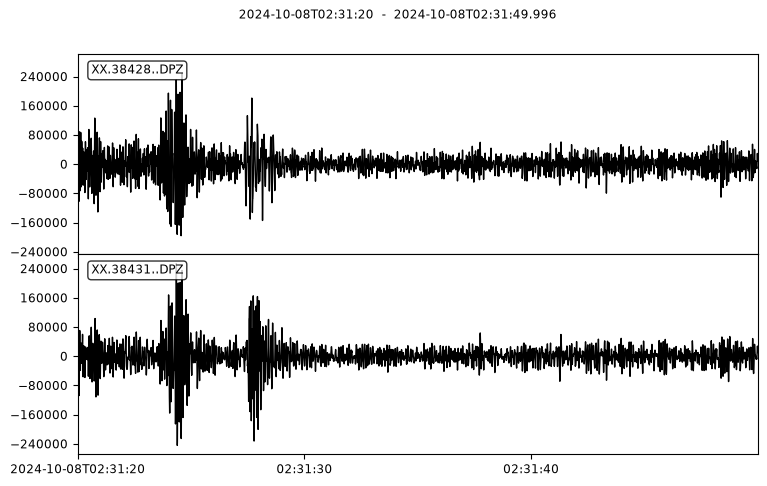

In [12]:
st_m.copy().select(component="Z").filter("bandpass", freqmin=2, freqmax=40).plot();

## 7. One call: convert every DLD recording on a drive

In [13]:
sel_all, inv_all, files = wf.convert_dld(NODES, out_dir="../output/dld_all", log_root=NODES,
                                        out_format="MSEED", chunk="1D")
print(inv_all.get_contents()["stations"])
sorted(str(p).split("dld_all/")[1] for p in files)

['XX.22317 (SmartSolo 453022317 (453022317_dld001))', 'XX.27665 (SmartSolo 453027665 (453027665_dld006))', 'XX.38428 (SmartSolo 453038428 (453038428_002))', 'XX.38431 (SmartSolo 453038431 (453038431_003))']


['mseed/XX/22317/XX.22317..GPE__20241225T180857Z__20241225T181159Z.mseed',
 'mseed/XX/22317/XX.22317..GPN__20241225T180857Z__20241225T181159Z.mseed',
 'mseed/XX/22317/XX.22317..GPZ__20241225T180857Z__20241225T181159Z.mseed',
 'mseed/XX/27665/XX.27665..GPE__20250211T203718Z__20250211T203830Z.mseed',
 'mseed/XX/27665/XX.27665..GPN__20250211T203718Z__20250211T203830Z.mseed',
 'mseed/XX/27665/XX.27665..GPZ__20250211T203718Z__20250211T203830Z.mseed',
 'mseed/XX/38428/XX.38428..DPE__20241008T022523Z__20241008T023458Z.mseed',
 'mseed/XX/38428/XX.38428..DPN__20241008T022523Z__20241008T023458Z.mseed',
 'mseed/XX/38428/XX.38428..DPZ__20241008T022523Z__20241008T023458Z.mseed',
 'mseed/XX/38431/XX.38431..DPE__20241008T022519Z__20241008T023542Z.mseed',
 'mseed/XX/38431/XX.38431..DPN__20241008T022519Z__20241008T023542Z.mseed',
 'mseed/XX/38431/XX.38431..DPZ__20241008T022519Z__20241008T023542Z.mseed']

Notes
- Raw DLD counts include the preamp gain; `build_inventory(gain_db="auto")` adds it to the response from the log's `Channel 1 Gain` (here 18 dB). For nodes without a log the gain is unknown and taken as 0 dB – pass `gain_db=` if you know it.
- The log's `Sample Rate` is the sample interval in 10 µs units: 100 → 1000 sps (the DML nodes), 400 → 250 sps, 200 → 500 sps.
- Channel codes follow the sample rate: `DP?` at 250/500 sps, `GP?` at 1000 sps.